# Week 1 — Panel (Longitudinal) Data: A Healthcare Example

**Maths for Data Science II**

**Panel data** follow the **same units** over **several time periods** — both dimensions at once.

Key features:

- Rows are identified by a **composite index** `(patient_id, date)`; neither column alone identifies a row
- $N$ units $\times$ $T$ periods, so $N \times T$ rows
- Contains a cross-sectional dimension **and** a time dimension, so it inherits properties of both
- Expensive to collect, but the richest of the four structures

Here: **50 patients** followed over **24 months**. This notebook only sets up and explores the
**structure** of such a dataset — no modelling yet.

## 1. Setup

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
rng = np.random.default_rng(2024)

## 2. Build the dataset

| Variable | Description | Varies over... |
|---|---|---|
| `patient_id` | unit identifier | — (the index) |
| `date` | month of check-up | — (the index) |
| `sex` | 0 = female, 1 = male | patients only (**time-invariant**) |
| `sbp` | systolic blood pressure (mmHg) | patients **and** time |
| `on_medication` | 0/1, switches on at that patient's own start month | patients **and** time |

Each patient attends a monthly check-up, and each starts medication in a different month.

In [14]:
N, T = 50, 24

dates = pd.date_range("2024-01-31", periods=T, freq="ME")

baseline = rng.normal(150, 10, size=N)             # each patient's usual blood pressure level
sex = rng.integers(0, 2, size=N)
start = rng.integers(1, T + 1, size=N)             # month each patient starts medication

rows = []
for i in range(N):
    for t in range(T):
        med = int(t + 1 >= start[i])
        sbp = baseline[i] - 12 * med + rng.normal(0, 4)
        rows.append((i + 1, dates[t], sex[i], round(sbp, 1), med))

panel = pd.DataFrame(rows, columns=["patient_id", "date", "sex", "sbp", "on_medication"])
panel.head(12)

,patient_id,date,sex,sbp,on_medication
0,1,2024-01-31,1,156.9,0
1,1,2024-02-29,1,161.9,0
2,1,2024-03-31,1,150.3,0
3,1,2024-04-30,1,160.1,0
4,1,2024-05-31,1,159.0,0
5,1,2024-06-30,1,158.2,0
6,1,2024-07-31,1,169.6,0
7,1,2024-08-31,1,150.4,0
8,1,2024-09-30,1,148.2,1
9,1,2024-10-31,1,148.6,1


## 3. Inspect the structure

One row per patient-month: 50 patients $\times$ 24 months.

In [15]:
print("Shape:", panel.shape, "=", panel.patient_id.nunique(), "patients x", panel.date.nunique(), "months")
print("Balanced panel?", len(panel) == panel.patient_id.nunique() * panel.date.nunique())
print()
print("patient_id alone unique?         ", panel['patient_id'].is_unique)
print("date alone unique?               ", panel['date'].is_unique)
print("(patient_id, date) pair unique?  ", not panel.duplicated(['patient_id', 'date']).any())

Shape: (1200, 5) = 50 patients x 24 months
Balanced panel? True

patient_id alone unique?          False
date alone unique?                False
(patient_id, date) pair unique?   True


Neither column identifies a row on its own — **that is the signature of panel data**.
A cross-section would be unique on `patient_id`; a time series would be unique on `date`.

In [16]:
# The composite index makes the two dimensions explicit
panel_idx = panel.set_index(["patient_id", "date"]).sort_index()
panel_idx.head(6)

sex    sbp  on_medication
patient_id date                                 
1          2024-01-31    1  156.9              0
           2024-02-29    1  161.9              0
           2024-03-31    1  150.3              0
           2024-04-30    1  160.1              0
           2024-05-31    1  159.0              0
           2024-06-30    1  158.2              0

## 4. A panel contains the other structures inside it

**Fix the patient** and you are left with a time series.

In [17]:
panel[panel.patient_id == 3].head(8)

,patient_id,date,sex,sbp,on_medication
48,3,2024-01-31,1,163.9,0
49,3,2024-02-29,1,164.4,0
50,3,2024-03-31,1,155.4,0
51,3,2024-04-30,1,165.2,0
52,3,2024-05-31,1,158.9,0
53,3,2024-06-30,1,165.7,0
54,3,2024-07-31,1,163.7,0
55,3,2024-08-31,1,160.9,0


**Fix the date** and you are left with a cross-section.

In [18]:
panel[panel.date == dates[0]].head(8)

,patient_id,date,sex,sbp,on_medication
0,1,2024-01-31,1,156.9,0
24,2,2024-01-31,0,167.8,0
48,3,2024-01-31,1,163.9,0
72,4,2024-01-31,0,141.6,0
96,5,2024-01-31,1,131.5,0
120,6,2024-01-31,0,151.9,0
144,7,2024-01-31,1,164.9,0
168,8,2024-01-31,1,152.9,0


In [19]:
print("One patient, all months  :", panel[panel.patient_id == 3].shape, "-> time series (T rows)")
print("All patients, one month   :", panel[panel.date == dates[0]].shape, "-> cross-section (N rows)")
print("Everything                :", panel.shape, "-> panel (N x T rows)")

One patient, all months  : (24, 5) -> time series (T rows)
All patients, one month   : (50, 5) -> cross-section (N rows)
Everything                : (1200, 5) -> panel (N x T rows)


## 5. How many observations per patient?

In a **balanced** panel every patient appears in every period. If patients dropped out
(**attrition**) the counts would differ and the panel would be **unbalanced**.

In [20]:
counts = panel.groupby("patient_id").size()
print("Observations per patient: min =", counts.min(), ", max =", counts.max())
counts.head()

Observations per patient: min = 24 , max = 24


patient_id
1    24
2    24
3    24
4    24
5    24
dtype: int64

## 6. Visualise both dimensions

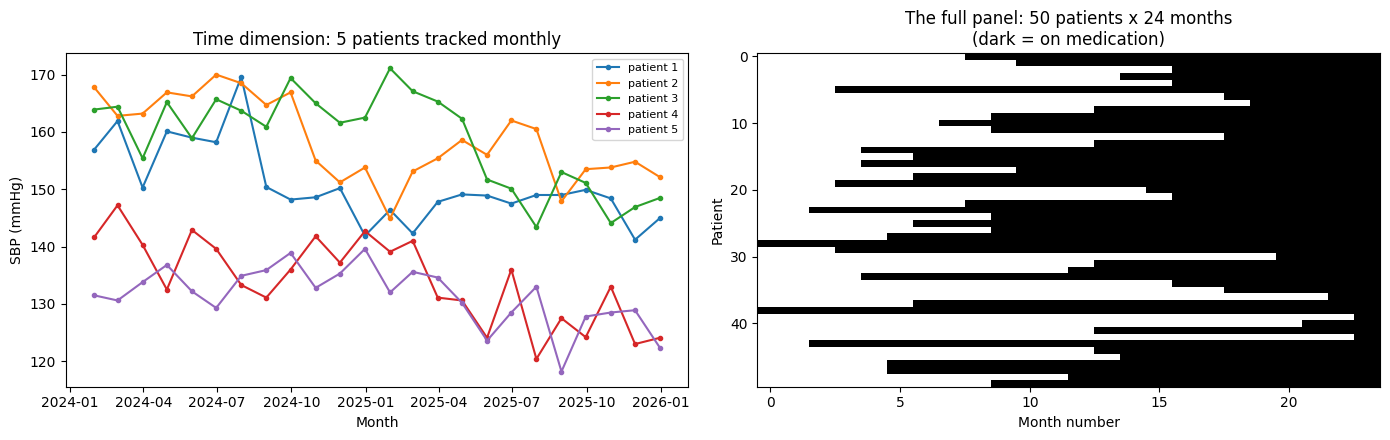

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Left: the time dimension, for a handful of patients
for i in [1, 2, 3, 4, 5]:
    d = panel[panel.patient_id == i]
    axes[0].plot(d["date"], d["sbp"], marker="o", ms=3, label=f"patient {i}")
axes[0].set_title("Time dimension: 5 patients tracked monthly")
axes[0].set_ylabel("SBP (mmHg)")
axes[0].set_xlabel("Month")
axes[0].legend(fontsize=8)

# Right: who is on medication when - the whole panel as a grid
grid = panel.pivot(index="patient_id", columns="date", values="on_medication")
axes[1].imshow(grid.values, aspect="auto", cmap="Greys", interpolation="nearest")
axes[1].set_title("The full panel: 50 patients x 24 months\n(dark = on medication)")
axes[1].set_xlabel("Month number")
axes[1].set_ylabel("Patient")

plt.tight_layout()
plt.show()

The right-hand panel is a picture of the dataset itself: every cell is one row of the table.
Each patient switches to medication at their own month, so the treatment varies **across patients**
and **over time** — variation only panel data can show you.

## Recap — the four structures, same clinic

| Data type | Units $N$ | Periods $T$ | Rows | Unique on |
|---|---|---|---|---|
| Cross-sectional | 200 | 1 | 200 | `patient_id` |
| Time series | 1 | 24 | 24 | `date` |
| Pooled cross sections | new sample each period | 2+ | varies | `(sample, date)` |
| **Panel / longitudinal** | **50** | **24** | **1,200** | **`(patient_id, date)`** |

Having both dimensions is what makes panel data valuable — how we exploit that comes later in the course.